<a href="https://colab.research.google.com/github/HouJiaqi524/code_vision/blob/main/PML_%E5%8D%95%E5%8F%98%E9%87%8F%E6%A8%A1%E5%9E%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
! pip3 install torch torchvision torchaudio

In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
import os
os.chdir('/content/drive/MyDrive/representation_learning')
!ls

 10%XRMB_2022_03_01_TD_Generator_Param.pkl
'2022.01_CNN_copula_U(0,1)矩约束_L2distance-.ipynb'
'2022.01_copula_rho独立约束_U(0,1)矩约束_L2distance_25g.ipynb'
'2022.01_copula_U(0,1)矩约束_L2distance.ipynb'
'2022.01_TD_copula_rho独立约束_U(0,1)矩约束_L2distance_25g.ipynb'
'2022.02_TD_copula_rho独立约束_U(0,1)矩约束_L2distance copy.ipynb'
 50epochs_2022_02_14_Generator_Param.pkl
 copula+GAN.ipynb
 copula+GAN的25gRAM.ipynb
'copula+KL+L2distance 的25gRAM.ipynb'
'L2+copula+GAN 的25gRAM.ipynb'
'MNIST2022.02_TD_copula_rho独立约束_U(0,1)矩约束_L2distance_25g.ipynb'
 MonotonicNN.py
 NeuralIntegral.py
'New_version_copula_U(0,1)矩约束_L2distance.ipynb'
 ParallelNeuralIntegral.py
 PML_单变量模型.ipynb
 __pycache__
 t10k-images-idx3-ubyte.gz
 t10k-labels-idx1-ubyte.gz
 train-images-idx3-ubyte.gz
 training_testing_data_corrnet
 train-labels-idx1-ubyte.gz
 utils_.py
 utils.py
 XRMB2022_02_22_TD_Generator_Param.pkl
'XRMB2022.02_TD_copula_rho独立约束_U(0,1)矩约束_L2distance_25g.ipynb'
 XRMB_2022_03_01_TD_Generator_Param.pkl
 XRMB_2022_03_01_train_ksi.csv

# 1 MNIST 二分类
## !导入数据

In [82]:
## 导入LeCun1998的MNIST数据集
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from utils_ import load_image, load_label


train_x = load_image('train-images-idx3-ubyte.gz').astype(float) #<class 'numpy.ndarray'> (5000, 28, 28) float64(原来都是Uint8)
train_y_np = load_label('train-labels-idx1-ubyte.gz').astype(int).squeeze() #<class 'numpy.ndarray'> (5000, ) int64
test_x = load_image('t10k-images-idx3-ubyte.gz').astype(float)[0:500,:] #<class 'numpy.ndarray'> (500, 28, 28) float64
test_y_np = load_label('t10k-labels-idx1-ubyte.gz').astype(int).squeeze()[0:500] #<class 'numpy.ndarray'>(500, ) int64

## MNIST 二维图片拉长
train_x = np.array( [ dt.flatten() for dt in train_x ] )  #<class 'numpy.ndarray'>(50000, 784)
test_x = np.array( [ dt.flatten() for dt in test_x ] ) #<class 'numpy.ndarray'>(500, 784) 


#转换数据为tensor类型 torch.tensor默认数据类型torch.float=torch.float32
train_x = torch.tensor(train_x, dtype=torch.float) #torch.Size([60000, 392]), torch.float32
train_y = torch.tensor(train_y_np, dtype=torch.float)   #torch.Size([60000]), torch.float32

test_x = torch.tensor(test_x, dtype=torch.float)   #torch.Size([10000, 392]), torch.float32
test_y = torch.tensor(test_y_np, dtype=torch.float)     #torch.Size([10000]), torch.float32

##将数据移到GPU上
device = torch.device(("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)

train_x = train_x.to(device)
train_y = train_y.to(device)

test_x = test_x.to(device)
test_y = test_y.to(device)

loading image ...
loading label ...
loading image ...
loading label ...
cpu


# 2 多分类模型

In [83]:
import torch.nn as nn
import torch.utils.data as Data
import math 
from tqdm import *

class Classifier_Lin(nn.Module):
    def __init__(self, input_dim: int=784):
        super(Classifier_Lin, self).__init__()
        self.dense =nn.Sequential(
            nn.Linear(input_dim, 10), 
            nn.ReLU()   
        )
          
    def forward(self, x):
        out = self.dense(x)
        return out


class Classifier_NonLin(nn.Module):
    def __init__(self, input_dim: int=784):
        super(Classifier_NonLin, self).__init__()
        self.dense =nn.Sequential(
            nn.Linear(input_dim, 500),
            nn.ReLU(),
            nn.BatchNorm1d(500),
            
            nn.Linear(500, 500),
            nn.ReLU(),
            nn.BatchNorm1d(500),
            
            nn.Linear(500, 10)         
        )
        
    def forward(self, x):
        out = self.dense(x)
        return out



##

## 1 cross entropy loss,线性模型

In [84]:
def test(C1):
    y_pre = C1(test_x)
    _,pre_index= torch.max(y_pre,1)
    pre_index= pre_index.view(-1)
    prediction = pre_index.detach().numpy()
    print(prediction.shape)
    print(test_y.shape)
    correct  = np.sum(prediction == test_y_np)
    return correct / 500.0


def train(batch_size: int=50):
    input_dim = 784
    output_dim = 10
    batch_size = batch_size
    
    ## Models
    C1 = Classifier_Lin(input_dim)
    C1 = C1.to(device)

    #C1 = Classifier_NonLin(input_dim)
    #C1 = C1.to(device)

    ## Optimizer
    C1_optim = torch.optim.Adam(C1.parameters(), lr=0.001)
    #C2_optim = torch.optim.Adam(C2.parameters(), lr=0.001)

    ## loss
    loss = nn.CrossEntropyLoss()



    ## 将数据分批
    torch_dataset = Data.TensorDataset(train_x, train_y)
    loader = Data.DataLoader(
        dataset = torch_dataset,
        batch_size = batch_size,
        shuffle = True
    )
    
    ## 用于存储generator的loss,及一些精度
    
    ## 反向传播
    for epoch in tqdm(range(3)):
        for i, (batch_x, batch_y) in tqdm(enumerate(loader)):
            
            ## 每次迭代梯度清零
            C1.zero_grad()
            #C2.zero_grad()
            

            ## generator的输出
            out = C1(batch_x)    
  
            loss_ = loss(out, batch_y.long())
            C1_optim.zero_grad()
            loss_.backward()
            C1_optim.step()
            
            if i != 0 and i % 20 ==0:
                print("=" * 10,i,"="*5,"="*5, "test accuracy is ",test(C1) ,"=" * 10 )

In [85]:
train(50)

  0%|          | 0/3 [00:00<?, ?it/s]
0it [00:00, ?it/s]
30it [00:00, 295.40it/s]
65it [00:00, 325.63it/s]

(500,)
torch.Size([500])
========== 20 ===== ===== test accuracy is  0.184 ==========
(500,)
torch.Size([500])
========== 40 ===== ===== test accuracy is  0.198 ==========
(500,)
torch.Size([500])
========== 60 ===== ===== test accuracy is  0.202 ==========
(500,)
torch.Size([500])
========== 80 ===== ===== test accuracy is  0.198 ==========



108it [00:00, 370.47it/s]
147it [00:00, 377.21it/s]

(500,)
torch.Size([500])
========== 100 ===== ===== test accuracy is  0.182 ==========
(500,)
torch.Size([500])
========== 120 ===== ===== test accuracy is  0.192 ==========
(500,)
torch.Size([500])
========== 140 ===== ===== test accuracy is  0.206 ==========
(500,)
torch.Size([500])
========== 160 ===== ===== test accuracy is  0.202 ==========
(500,)
torch.Size([500])
========== 180 ===== ===== test accuracy is  0.202 ==========



194it [00:00, 407.94it/s]
241it [00:00, 427.74it/s]
284it [00:00, 409.99it/s]

...

(500,)
torch.Size([500])
========== 900 ===== ===== test accuracy is  0.33 ==========
(500,)
torch.Size([500])
========== 920 ===== ===== test accuracy is  0.304 ==========
(500,)
torch.Size([500])
========== 940 ===== ===== test accuracy is  0.308 ==========
(500,)
torch.Size([500])
========== 960 ===== ===== test accuracy is  0.32 ==========
(500,)
torch.Size([500])
========== 980 ===== ===== test accuracy is  0.34 ==========
(500,)
torch.Size([500])
========== 1000 ===== ===== test accuracy is  0.322 ==========



1014it [00:02, 470.96it/s]
1072it [00:02, 500.97it/s]
1124it [00:02, 504.66it/s]

(500,)
torch.Size([500])
========== 1020 ===== ===== test accuracy is  0.32 ==========
(500,)
torch.Size([500])
========== 1040 ===== ===== test accuracy is  0.33 ==========
(500,)
torch.Size([500])
========== 1060 ===== ===== test accuracy is  0.31 ==========
(500,)
torch.Size([500])
========== 1080 ===== ===== test accuracy is  0.328 ==========
(500,)
torch.Size([500])
========== 1100 ===== ===== test accuracy is  0.288 ==========
(500,)
torch.Size([500])
========== 1120 ===== ===== test accuracy is  0.29 ==========



1200it [00:02, 476.23it/s]
100%|██████████| 3/3 [00:10<00:00,  3.34s/it]

(500,)
torch.Size([500])
========== 1140 ===== ===== test accuracy is  0.286 ==========
(500,)
torch.Size([500])
========== 1160 ===== ===== test accuracy is  0.302 ==========
(500,)
torch.Size([500])
========== 1180 ===== ===== test accuracy is  0.308 ==========


## 2 cross entropy loss,非线性模型

In [86]:
def test(C1):
    y_pre = C1(test_x)
    _,pre_index= torch.max(y_pre,1)
    pre_index= pre_index.view(-1)
    prediction = pre_index.detach().numpy()
    print(prediction.shape)
    print(test_y.shape)
    correct  = np.sum(prediction == test_y_np)
    return correct / 500.0


def train(batch_size: int=50):
    input_dim = 784
    output_dim = 10
    batch_size = batch_size
    
    ## Models
    #C1 = Classifier_Lin(input_dim)
    #C1 = C1.to(device)

    C1 = Classifier_NonLin(input_dim)
    C1 = C1.to(device)

    ## Optimizer
    C1_optim = torch.optim.Adam(C1.parameters(), lr=0.001)
    #C2_optim = torch.optim.Adam(C2.parameters(), lr=0.001)

    ## loss
    loss = nn.CrossEntropyLoss(reduction='sum')



    ## 将数据分批
    torch_dataset = Data.TensorDataset(train_x, train_y)
    loader = Data.DataLoader(
        dataset = torch_dataset,
        batch_size = batch_size,
        shuffle = True
    )
    
    ## 用于存储generator的loss,及一些精度
    CEL = list()
    
    ## 反向传播
    for epoch in tqdm(range(3)):
        for i, (batch_x, batch_y) in tqdm(enumerate(loader)):
            
            ## 每次迭代梯度清零
            C1.zero_grad()
            #C2.zero_grad()
            

            ## generator的输出
            out = C1(batch_x)    
  
            loss_ = loss(out, batch_y.long())
            C1_optim.zero_grad()
            loss_.backward()
            C1_optim.step()
            
            if i != 0 and i % 20 ==0:
                print("=" * 10,i,"="*5,"="*5, "test accuracy is ",test(C1) ,"=" * 10 )


In [87]:
train(50)

  0%|          | 0/3 [00:00<?, ?it/s]
0it [00:00, ?it/s]
6it [00:00, 59.83it/s]
13it [00:00, 63.51it/s]
21it [00:00, 61.69it/s]
28it [00:00, 63.35it/s]

(500,)
torch.Size([500])
========== 20 ===== ===== test accuracy is  0.876 ==========



35it [00:00, 64.11it/s]
42it [00:00, 57.84it/s]
49it [00:00, 60.17it/s]

(500,)
torch.Size([500])
========== 40 ===== ===== test accuracy is  0.894 ==========



56it [00:00, 61.20it/s]
63it [00:01, 59.33it/s]
70it [00:01, 61.39it/s]

...


1155it [00:22, 51.83it/s]
1161it [00:23, 51.45it/s]
1167it [00:23, 52.11it/s]

(500,)
torch.Size([500])
========== 1160 ===== ===== test accuracy is  0.982 ==========



1173it [00:23, 52.16it/s]
1179it [00:23, 52.20it/s]
1185it [00:23, 50.54it/s]
1191it [00:23, 51.10it/s]

(500,)
torch.Size([500])
========== 1180 ===== ===== test accuracy is  0.98 ==========



1200it [00:23, 50.31it/s]
100%|██████████| 3/3 [01:07<00:00, 22.63s/it]


## 3 手动写loss，非线性模型

In [91]:
def LL(y_out, y_true):
    n = y_out.shape[0]
    ll=0
    for i in range(n):
        
        z = torch.sum(torch.exp(y_out[i,:]))
        a = torch.exp(y_out[i,:])/z
        #print(a)

        c = y_true[i]
        t = [0]*10
        t = torch.Tensor( [ 1 if c==j else k   for (j,k) in enumerate(t)] )  
        #print(t)
        #print(c)
        ll = ll - torch.sum(torch.mul(torch.log(a), t))

    return ll

def test(C1):
    y_pre = C1(test_x)
    _,pre_index= torch.max(y_pre,1)
    pre_index= pre_index.view(-1)
    prediction = pre_index.detach().numpy()
    print(prediction.shape)
    print(test_y.shape)
    correct  = np.sum(prediction == test_y_np)
    return correct / 500.0


def train(batch_size: int=50):
    input_dim = 784
    output_dim = 10
    batch_size = batch_size
    
    ## Models
    #C1 = Classifier_Lin(input_dim)
    #C1 = C1.to(device)

    C1 = Classifier_NonLin(input_dim)
    C1 = C1.to(device)

    ## Optimizer
    C1_optim = torch.optim.Adam(C1.parameters(), lr=0.001)
    #C2_optim = torch.optim.Adam(C2.parameters(), lr=0.001)

    ## loss
    loss = nn.CrossEntropyLoss(reduction='sum')



    ## 将数据分批
    torch_dataset = Data.TensorDataset(train_x, train_y)
    loader = Data.DataLoader(
        dataset = torch_dataset,
        batch_size = batch_size,
        shuffle = True
    )
    
    ## 用于存储generator的loss,及一些精度
    CEL = list()
    manulLoss = list()
    
    ## 反向传播
    for epoch in tqdm(range(3)):
        for i, (batch_x, batch_y) in tqdm(enumerate(loader)):
            
            ## 每次迭代梯度清零
            C1.zero_grad()
            #C2.zero_grad()
            

            ## generator的输出
            out = C1(batch_x)    
  
            loss1 = LL(out, batch_y.long())
            loss2 = loss(out, batch_y.long())
            C1_optim.zero_grad()
            loss1.backward()
            C1_optim.step()
            
            if i != 0 and i % 20 ==0:
                b1 = loss1.cpu().clone()
                CEL.append(b1.tolist())
                b2 = loss2.cpu().clone()
                manulLoss.append(b2.tolist())

                print("=" * 10,i,"="*5,"="*5, "test accuracy is ",test(C1) ,"=" * 10 )

    return CEL, manulLoss

In [92]:
CEL, manulLoss = train(50)

  0%|          | 0/3 [00:00<?, ?it/s]
0it [00:00, ?it/s]
4it [00:00, 35.62it/s]
8it [00:00, 37.17it/s]
12it [00:00, 37.22it/s]
16it [00:00, 36.50it/s]
20it [00:00, 36.64it/s]
24it [00:00, 33.53it/s]
28it [00:00, 34.86it/s]

(500,)
torch.Size([500])
========== 20 ===== ===== test accuracy is  0.87 ==========



32it [00:00, 34.69it/s]
36it [00:01, 35.33it/s]
40it [00:01, 35.44it/s]
44it [00:01, 33.71it/s]
48it [00:01, 34.29it/s]

(500,)
torch.Size([500])
========== 40 ===== ===== test accuracy is  0.902 ==========



52it [00:01, 35.22it/s]
56it [00:01, 35.71it/s]
60it [00:01, 35.85it/s]
64it [00:01, 34.17it/s]

...


1149it [00:38, 27.62it/s]
1152it [00:38, 28.12it/s]
1155it [00:38, 27.78it/s]
1158it [00:39, 28.29it/s]
1161it [00:39, 27.81it/s]
1164it [00:39, 28.43it/s]

(500,)
torch.Size([500])
========== 1160 ===== ===== test accuracy is  0.978 ==========



1167it [00:39, 28.67it/s]
1170it [00:39, 28.47it/s]
1173it [00:39, 28.47it/s]
1176it [00:39, 28.17it/s]
1179it [00:39, 28.36it/s]
1182it [00:39, 26.25it/s]
1185it [00:40, 26.22it/s]

(500,)
torch.Size([500])
========== 1180 ===== ===== test accuracy is  0.976 ==========



1188it [00:40, 25.77it/s]
1191it [00:40, 26.36it/s]
1194it [00:40, 27.16it/s]
1197it [00:40, 27.37it/s]
1200it [00:40, 29.55it/s]
100%|██████████| 3/3 [01:55<00:00, 38.62s/it]


(177, 1)
<class 'numpy.ndarray'>


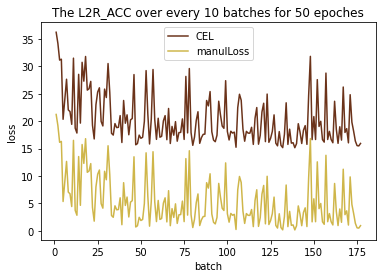

In [102]:
# 绘制loss的折线图
import matplotlib.pyplot as plt
import numpy as np


CEL = np.array(CEL).reshape((-1,1)) #
print(CEL.shape)
print(type(CEL))

x = np.arange(1, CEL.shape[0]+1)

plt.plot(x, CEL+15, '#6B331A', label='CEL')
plt.plot(x, manulLoss, '#CFB64A', label='manulLoss')

plt.title('The L2R_ACC over every 10 batches for 50 epoches')
plt.xlabel('batch')
plt.ylabel('loss')

plt.legend() # 让plt.plot()中的label显示出来
#plt.show()

